# Yasmine El Hakem RT4/1

# Lab 3: Convolutional Neural Networks (CNN)

In this lab, we build a Convolutional Neural Network (CNN) to recognize handwritten digits. Using the MNIST dataset provided by Keras, which contains labeled images of handwritten numbers from 0 to 9, we train three different neural network models and compare their performance. The goal is to evaluate how different architectures impact the accuracy of digit recognition.

## Building the First Network

In [34]:
import numpy as np
from keras.datasets import mnist
from keras.utils import to_categorical
from keras import backend as K

In [35]:
K.set_image_data_format('channels_first')

In [36]:
seed = 7
np.random.seed(seed)

In [37]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D

In [38]:
# load data
(X_train, y_train),(X_test, y_test) = mnist.load_data()

In [39]:
def get_data_mnist():
    (X_train, y_train), (X_test, y_test) = mnist.load_data()

    # reshape images
    X_train = X_train.reshape(X_train.shape[0], 1, 28, 28).astype('float32')
    X_test = X_test.reshape(X_test.shape[0], 1, 28, 28).astype('float32')

    # normalize
    X_train = X_train / 255
    X_test = X_test / 255

    # one hot encoding
    y_train = to_categorical(y_train)
    y_test = to_categorical(y_test)

    num_classes = y_test.shape[1]

    return (X_train, y_train), (X_test, y_test), num_classes


In [40]:
(X_train, y_train), (X_test, y_test), num_classes = get_data_mnist()


In [41]:
def small_model():
    model = Sequential()
    num_classes = 10

    model.add(Conv2D(64, (3, 3), input_shape=(1, 28, 28), activation='relu'))
    model.add(Conv2D(32, (3, 3), activation='relu'))
    model.add(Flatten())
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model

In [42]:
model = small_model()

model.fit(X_train, y_train,
          validation_data=(X_test, y_test),
          epochs=10,
          batch_size=200)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 81s 263ms/step - accuracy: 0.9354 - loss: 0.2254 - val_accuracy: 0.9782 - val_loss: 0.0716
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 79s 263ms/step - accuracy: 0.9807 - loss: 0.0670 - val_accuracy: 0.9844 - val_loss: 0.0496
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 70s 233ms/step - accuracy: 0.9861 - loss: 0.0463 - val_accuracy: 0.9853 - val_loss: 0.0468
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 68s 227ms/step - accuracy: 0.9893 - loss: 0.0342 - val_accuracy: 0.9856 - val_loss: 0.0467
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 72s 241ms/step - accuracy: 0.9908 - loss: 0.0283 - val_accuracy: 0.9864 - val_loss: 0.0440
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 67s 223ms/step - accuracy: 0.9936 - loss: 0.0207 - val_accuracy: 0.9868 - val_loss: 0.0424
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 97s 323ms/step - accuracy: 0.9952 - loss: 0.0161 - val_accuracy: 0.9852 - val_loss: 0.0513
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 102s 341ms/step - accuracy: 0.9963 - loss: 

In [43]:
def print_model_error_rate(model, X_test, y_test):
# Final evaluation of the model 
    scores = model.evaluate(X_test, y_test, verbose=0)
    print("Model score : %.2f%%" % (scores[1]*100))
    print("Model error rate : %.2f%%" % (100-scores[1]*100))

In [44]:
print_model_error_rate(model, X_test, y_test)

Model score : 98.38%
Model error rate : 1.62%


## Data Normalization
In the first model, pixel values were kept as integers between 0 and 255. In the improved versions, these values are converted to floating-point numbers and divided by 255 to scale them between 0 and 1.

This normalization step is essential in deep learning because it reduces the gap between extreme values and ensures numerical stability during training. Working with smaller, standardized values helps prevent overflow issues and allows the neural network to converge faster and more efficiently.

In [45]:
def get_data_mnist2():
    (X_train, y_train), (X_test, y_test) = mnist.load_data()

    # reshape images
    X_train = X_train.reshape(X_train.shape[0], 1, 28, 28).astype('float32')
    X_test = X_test.reshape(X_test.shape[0], 1, 28, 28).astype('float32')

    # normalisation (valeurs entre 0 et 1)
    X_train = X_train / 255
    X_test = X_test / 255

    # one hot encoding
    y_train = to_categorical(y_train)
    y_test = to_categorical(y_test)

    num_classes = y_test.shape[1]

    return (X_train, y_train), (X_test, y_test), num_classes

## Building the second model

In [47]:
def medium_model():
    model = Sequential()
    num_classes = 10

    model.add(Conv2D(32, (5, 5), input_shape=(1, 28, 28), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model

# Entraînement et évaluation
(X_train, y_train), (X_test, y_test), num_classes = get_data_mnist2()

model_medium = medium_model()
model_medium.fit(X_train, y_train,
                 validation_data=(X_test, y_test),
                 epochs=10,
                 batch_size=200)

print_model_error_rate(model_medium, X_test, y_test)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.9306 - loss: 0.2428 - val_accuracy: 0.9715 - val_loss: 0.0871
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.9778 - loss: 0.0736 - val_accuracy: 0.9824 - val_loss: 0.0531
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.9843 - loss: 0.0521 - val_accuracy: 0.9853 - val_loss: 0.0449
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.9877 - loss: 0.0408 - val_accuracy: 0.9873 - val_loss: 0.0367
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.9899 - loss: 0.0329 - val_accuracy: 0.9877 - val_loss: 0.0349
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.9916 - loss: 0.0272 - val_accuracy: 0.9880 - val_loss: 0.0380
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - accuracy: 0.9932 - loss: 0.0226 - val_accuracy: 0.9876 - val_loss: 0.0350
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.9940 - loss: 0.0194 - 

## Building the third model

In [48]:
def large_model():
    model = Sequential()
    num_classes = 10

    model.add(Conv2D(30, (5, 5), input_shape=(1, 28, 28), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Conv2D(15, (3, 3), activation='relu'))
    model.add(Dropout(0.2))
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model

# Entraînement et évaluation
model_large = large_model()
model_large.fit(X_train, y_train,
                validation_data=(X_test, y_test),
                epochs=10,
                batch_size=200)

print_model_error_rate(model_large, X_test, y_test)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 25s 68ms/step - accuracy: 0.9087 - loss: 0.3011 - val_accuracy: 0.9744 - val_loss: 0.0752
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.9768 - loss: 0.0782 - val_accuracy: 0.9839 - val_loss: 0.0484
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - accuracy: 0.9834 - loss: 0.0533 - val_accuracy: 0.9876 - val_loss: 0.0379
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - accuracy: 0.9860 - loss: 0.0437 - val_accuracy: 0.9909 - val_loss: 0.0289
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.9892 - loss: 0.0352 - val_accuracy: 0.9904 - val_loss: 0.0273
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.9910 - loss: 0.0291 - val_accuracy: 0.9894 - val_loss: 0.0345
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 58ms/step - accuracy: 0.9919 - loss: 0.0260 - val_accuracy: 0.9905 - val_loss: 0.0294
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - accuracy: 0.9931 - loss: 0.0217 - 

## Save models

In [52]:
def save_keras_model(model, filename):
    # Sérialisation de l'architecture en JSON
    model_json = model.to_json()
    with open(filename + ".json", "w") as json_file:
        json_file.write(model_json)

    # Sérialisation des poids en HDF5 (nouveau format Keras 3)
    model.save_weights(filename + ".weights.h5")
    print(f"Modèle sauvegardé : {filename}.json et {filename}.weights.h5")

## Load models

In [53]:
from keras.models import model_from_json

def load_keras_model(filename):
    json_file = open(filename + ".json", 'r')
    loaded_model_json = json_file.read()
    json_file.close()
    loaded_model = model_from_json(loaded_model_json)

    # Chargement avec le nouveau format
    loaded_model.load_weights(filename + ".weights.h5")
    print(f"Modèle chargé : {filename}.json et {filename}.weights.h5")

    return loaded_model

In [54]:
# Sauvegarde des modèles
save_keras_model(model, "small_cnn")
save_keras_model(model_medium, "medium_cnn")
save_keras_model(model_large, "large_cnn")

Modèle sauvegardé : small_cnn.json et small_cnn.weights.h5
Modèle sauvegardé : medium_cnn.json et medium_cnn.weights.h5
Modèle sauvegardé : large_cnn.json et large_cnn.weights.h5


In [56]:
# Chargement d'un modèle
loaded_small  = load_keras_model("small_cnn")
loaded_medium = load_keras_model("medium_cnn")
loaded_large  = load_keras_model("large_cnn")

# IMPORTANT : recompiler avant utilisation
loaded_small.compile(loss='categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])

loaded_medium.compile(loss='categorical_crossentropy',
                      optimizer='adam',
                      metrics=['accuracy'])

loaded_large.compile(loss='categorical_crossentropy',
                     optimizer='adam',
                     metrics=['accuracy'])

# Évaluation des modèles chargés
print(" Small CNN ")
print_model_error_rate(loaded_small, X_test, y_test)

print(" Medium CNN ")
print_model_error_rate(loaded_medium, X_test, y_test)

print(" Large CNN ")
print_model_error_rate(loaded_large, X_test, y_test)

Modèle chargé : small_cnn.json et small_cnn.weights.h5
Modèle chargé : medium_cnn.json et medium_cnn.weights.h5
Modèle chargé : large_cnn.json et large_cnn.weights.h5
 Small CNN 
Model score : 98.38%
Model error rate : 1.62%
 Medium CNN 
Model score : 99.00%
Model error rate : 1.00%
 Large CNN 
Model score : 99.11%
Model error rate : 0.89%


## Testing the Model with an image 
After training, saving, and loading the CNN models, we test their ability to recognize handwritten digits using an external image downloaded from the internet.
To ensure compatibility with the MNIST dataset used during training, the image must undergo the same preprocessing steps: converting it to grayscale, resizing it to 28×28 pixels, normalizing pixel values between 0 and 1, and reshaping it to match the model’s input format.
Once preprocessed, the image is passed to the trained model to predict the digit and obtain the probability for each class (0–9).

In [61]:
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

In [62]:
def preprocess_image(image_path):
    # Charger l'image
    img = Image.open(image_path)

    # Convertir en niveaux de gris
    img = img.convert('L')

    # Redimensionner en 28x28
    img = img.resize((28, 28))

    # Inverser les couleurs (MNIST = fond noir, chiffre blanc)
    img = ImageOps.invert(img)

    # Afficher l'image préprocessée
    plt.imshow(img, cmap='gray')
    plt.title("Image préprocessée")
    plt.axis('off')
    plt.show()

    # Convertir en array numpy
    img_array = np.array(img).astype('float32')

    # Normaliser entre 0 et 1
    img_array = img_array / 255

    # Reshape pour correspondre à input_shape=(1, 28, 28)
    # (1 sample, 1 canal, 28x28)
    img_array = img_array.reshape(1, 1, 28, 28)

    return img_array

In [63]:
def predict_digit(image_path, small, medium, large):
    # Préprocesser l'image
    img = preprocess_image(image_path)

    # Prédiction avec chaque modèle
    pred_small  = small.predict(img)
    pred_medium = medium.predict(img)
    pred_large  = large.predict(img)

    # Récupérer le chiffre prédit (index de la valeur max)
    digit_small  = np.argmax(pred_small)
    digit_medium = np.argmax(pred_medium)
    digit_large  = np.argmax(pred_large)

    # Afficher les résultats
    print("=" * 40)
    print(f"  Small  CNN  →  Chiffre prédit : {digit_small}  (confiance : {pred_small[0][digit_small]*100:.2f}%)")
    print(f"  Medium CNN  →  Chiffre prédit : {digit_medium}  (confiance : {pred_medium[0][digit_medium]*100:.2f}%)")
    print(f"  Large  CNN  →  Chiffre prédit : {digit_large}  (confiance : {pred_large[0][digit_large]*100:.2f}%)")
    print("=" * 40)

Modèle chargé : small_cnn.json et small_cnn.weights.h5
Modèle chargé : medium_cnn.json et medium_cnn.weights.h5
Modèle chargé : large_cnn.json et large_cnn.weights.h5


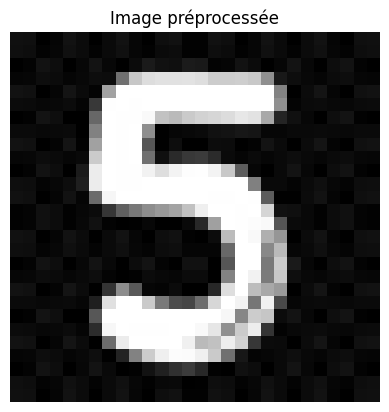

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
  Small  CNN  →  Chiffre prédit : 5  (confiance : 100.00%)
  Medium CNN  →  Chiffre prédit : 5  (confiance : 99.99%)
  Large  CNN  →  Chiffre prédit : 5  (confiance : 99.99%)


In [64]:
# Charger les modèles
loaded_small  = load_keras_model("small_cnn")
loaded_medium = load_keras_model("medium_cnn")
loaded_large  = load_keras_model("large_cnn")

# Recompiler les modèles
for m in [loaded_small, loaded_medium, loaded_large]:
    m.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Lancer la prédiction sur votre image
predict_digit("chiffre.png", loaded_small, loaded_medium, loaded_large)